In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clar04/alldata-split/dataset_with_split.csv


# M3 — CABiLSTM-IndoBERT + Focal Loss + Class Weighting (Multilabel Wide Format)

**Modified CABiLSTM-IndoBERT with algorithm-level class imbalance handling (RQ2).**

## Research Question
**RQ2**: Apakah Focal Loss + Class Weighting dapat meningkatkan performa pada kelas sentimen minoritas (neutral, negative) tanpa augmentasi data?

## Architecture (identical to M2-v2):
```
Input: [CLS] review_text [SEP]
  │
  ▼
IndoBERT
  ├─ Layers 0–7  : FROZEN
  └─ Layers 8–11 : TRAINABLE (lr=2e-5)
  │
  ▼
CABiLSTM (lr=5e-4) → Masked Mean Pooling
  │
  ▼
MLP: 1024 → 512 → 15 outputs
```

## Loss Function (the only change from M2-v2):
| | M2-v2 | **M3** |
|---|---|---|
| Loss | `masked_bce_loss` | **`masked_focal_bce_loss` (γ=2.0)** |
| Class weight | None | **Inverse frequency per sentiment class** |
| no_aspect slots | Masked out | **Masked out** (unchanged) |

## Focal Loss for Multilabel BCE:
$$FL(p_t) = -\alpha_t \cdot (1 - p_t)^{\gamma} \cdot \log(p_t)$$

Applied **per active slot** after masking. `no_aspect` slots contribute zero to loss.

## Class Weight Strategy:
- Computed from train set per **sentiment class** (negative/neutral/positive)
- Formula: `weight_c = N_total_sentiment / (3 × N_c)` (inverse frequency)
- Applied as `pos_weight` per sentiment slot in `BCEWithLogitsLoss`
- `no_aspect` slots are masked → weight irrelevant

**References**: Lin et al. (2017) ICCV; Fernando & Tsokos (2021).

---
## Section 1: Setup & Imports

In [2]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


---
## Section 2: Configuration & Constants

In [4]:
CONFIG = {
    # Model
    'model_name'          : 'indobenchmark/indobert-base-p1',
    'num_outputs'         : 15,        # 5 aspects × 3 sentiments
    'dropout'             : 0.3,
    # Tokenization
    'max_length'          : 128,
    # Training
    'batch_size'          : 16,
    'weight_decay'        : 0.01,
    'epochs'              : 10,
    'patience'            : 3,
    'warmup_ratio'        : 0.1,
    'grad_clip'           : 1.0,
    # Partial unfreeze (same as M2-v2)
    'num_unfrozen_layers' : 4,
    'lr_bert'             : 2e-5,
    'lr_cabilstm'         : 5e-4,
    # CABiLSTM architecture (He et al., 2025)
    'bilstm_hidden'       : 384,
    'attn_heads'          : 8,
    'conv_kernel'         : 5,
    'mlp_hidden_1'        : 1024,
    'mlp_hidden_2'        : 512,
    # Focal Loss + Class Weighting (M3-specific)
    'focal_gamma'         : 2.0,       # Lin et al. (2017)
    'use_class_weights'   : True,
    'seed'                : SEED,
}

ASPECTS    = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']
SENTIMENTS = ['negative', 'neutral', 'positive']   # index 0, 1, 2
SENT2ID    = {s: i for i, s in enumerate(SENTIMENTS)}
ID2SENT    = {i: s for s, i in SENT2ID.items()}

DATA_PATH           = '/kaggle/input/datasets/clar04/alldata-split/dataset_with_split.csv'
OUTPUT_DIR          = '/kaggle/working'
BEST_MODEL_PATH     = f'{OUTPUT_DIR}/m3_best.pt'
PREDICTIONS_PATH    = f'{OUTPUT_DIR}/m3_predictions.csv'
METRICS_PATH        = f'{OUTPUT_DIR}/m3_metrics.json'
LOSS_PLOT_PATH      = f'{OUTPUT_DIR}/m3_loss_convergence.png'
CM_PLOT_PATH        = f'{OUTPUT_DIR}/m3_confusion_matrix.png'
PERASPECT_PLOT_PATH = f'{OUTPUT_DIR}/m3_per_aspect_results.png'

assert os.path.exists(DATA_PATH), f'Dataset not found: {DATA_PATH}'
print('Config loaded.')
for k, v in CONFIG.items():
    print(f'  {k:<22} {v}')

Config loaded.
  model_name             indobenchmark/indobert-base-p1
  num_outputs            15
  dropout                0.3
  max_length             128
  batch_size             16
  weight_decay           0.01
  epochs                 10
  patience               3
  warmup_ratio           0.1
  grad_clip              1.0
  num_unfrozen_layers    4
  lr_bert                2e-05
  lr_cabilstm            0.0005
  bilstm_hidden          384
  attn_heads             8
  conv_kernel            5
  mlp_hidden_1           1024
  mlp_hidden_2           512
  focal_gamma            2.0
  use_class_weights      True
  seed                   42


---
## Section 3: Load Data & EDA

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df)}')
print('Split distribution:')
print(df['split'].value_counts().to_string())
display(df.head(3))

Total rows : 1098
Split distribution:
split
train    998
val       50
test      50


,review_id,review_text,product_name,product_brand,PIGMENTATION,LONGEVITY,TEXTURE,HYDRATION,PRICE,is_synthetic,source_fase,method,split
0,388,"Aku kira bakalan aroma strawberrynya kuat, ter...",24H Melt-In Moisture,Nivea,no_aspect,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
1,334,Beli produk ini tuh awalnya karena IKON hahaha...,24H Melt-In Moisture,Nivea,positive,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
2,142,My favorit lip balm!! enggak bikin bibir kerin...,24H Melt-In Moisture,Nivea,neutral,no_aspect,positive,positive,no_aspect,False,NaN,NaN,train


In [6]:
train_df = df[df['split'] == 'train']
print('Label distribution per aspect (train set):')
print(f'{"Aspect":<14} {"positive":>9} {"negative":>9} {"neutral":>9} {"no_aspect":>10} {"imb_ratio":>10}')
print('-' * 65)
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    pos, neg, neu, noa = (counts.get(k, 0) for k in ['positive', 'negative', 'neutral', 'no_aspect'])
    sents = [c for c in [pos, neg, neu] if c > 0]
    ratio = max(sents) / min(sents) if sents else 0
    print(f'{asp:<14} {pos:>9} {neg:>9} {neu:>9} {noa:>10} {ratio:>9.1f}:1')

Label distribution per aspect (train set):
Aspect          positive  negative   neutral  no_aspect  imb_ratio
-----------------------------------------------------------------
PIGMENTATION         377        98       172        351       3.8:1
LONGEVITY             93       193        40        672       4.8:1
TEXTURE              272       114        41        571       6.6:1
HYDRATION            584       176        85        153       6.9:1
PRICE                252        20        11        715      22.9:1


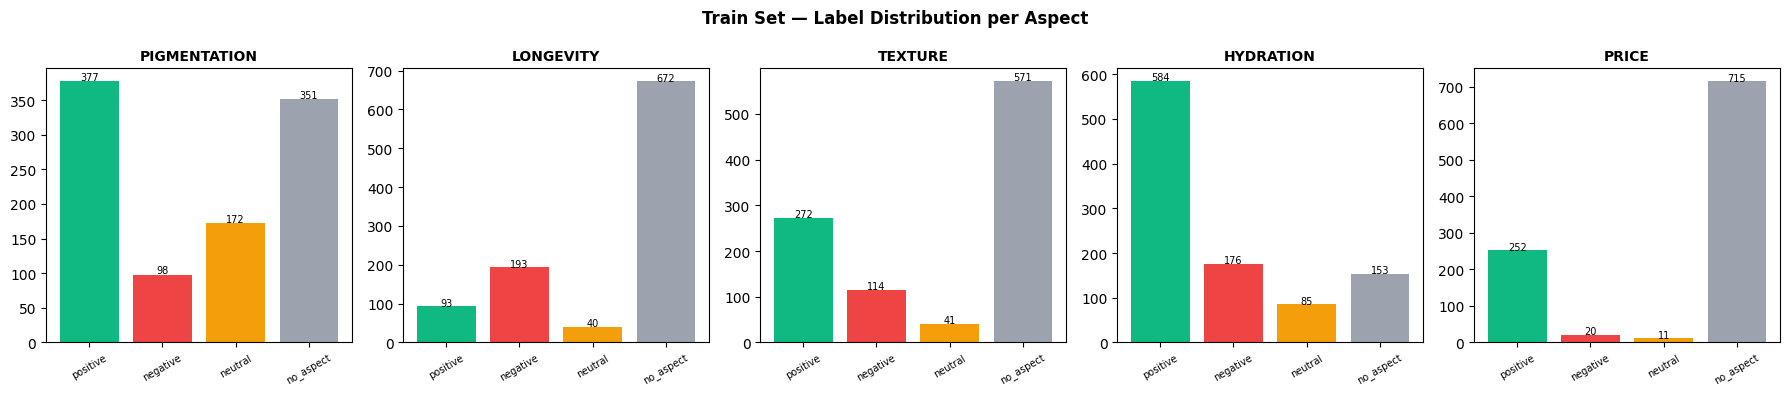

In [7]:
SENT_COLORS = {'negative': '#ef4444', 'neutral': '#f59e0b',
               'positive': '#10b981', 'no_aspect': '#9ca3af'}

fig, axes = plt.subplots(1, len(ASPECTS), figsize=(18, 4))
for ax, asp in zip(axes, ASPECTS):
    counts = train_df[asp].value_counts().reindex(
        ['positive', 'negative', 'neutral', 'no_aspect'], fill_value=0
    )
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[l] for l in counts.index])
    ax.set_title(asp, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v), ha='center', fontsize=7)
plt.suptitle('Train Set — Label Distribution per Aspect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Tokenizer & Dataset

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer : {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer : indobenchmark/indobert-base-p1
Vocab size: 30,521


In [9]:
class ABSADataset(Dataset):
    """
    Multilabel ABSA dataset — wide format.

    Input : [CLS] review_text [SEP]
    labels: float tensor (15,)  — one-hot per active (aspect, sentiment) slot
    mask  : float tensor (15,)  — 1.0 for slots where aspect != no_aspect

    Flat layout: [pig_neg, pig_neu, pig_pos, lon_neg, ..., pri_pos]
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = self.tokenizer(
            str(row['review_text']),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        labels = torch.zeros(15, dtype=torch.float)
        mask   = torch.zeros(15, dtype=torch.float)

        for asp_idx, asp in enumerate(ASPECTS):
            val  = row[asp]
            base = asp_idx * 3
            if val != 'no_aspect':
                labels[base + SENT2ID[val]] = 1.0
                mask[base : base + 3]       = 1.0

        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels'        : labels,
            'mask'          : mask,
            'review_id'     : str(row['review_id']),
        }

In [10]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

train_ds = ABSADataset(train_df, tokenizer, CONFIG['max_length'])
val_ds   = ABSADataset(val_df,   tokenizer, CONFIG['max_length'])
test_ds  = ABSADataset(test_df,  tokenizer, CONFIG['max_length'])

print(f'Train : {len(train_ds)} reviews')
print(f'Val   : {len(val_ds)} reviews')
print(f'Test  : {len(test_ds)} reviews')

s = train_ds[0]
print(f'\nSample 0 active aspects: '
      f'{[(ASPECTS[i], SENTIMENTS[j]) for i in range(5) for j in range(3) if s["labels"][i*3+j] == 1.0]}')

Train : 998 reviews
Val   : 50 reviews
Test  : 50 reviews

Sample 0 active aspects: [('HYDRATION', 'positive')]


---
## Section 5: DataLoader

In [11]:
def collate_fn(batch):
    return {
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids'] for b in batch]),
        'labels'        : torch.stack([b['labels']         for b in batch]),
        'mask'          : torch.stack([b['mask']           for b in batch]),
        'review_id'     : [b['review_id'] for b in batch],
    }

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

b = next(iter(train_loader))
print('\nBatch shapes:')
for k in ['input_ids', 'attention_mask', 'token_type_ids', 'labels', 'mask']:
    print(f'  {k:<16}: {b[k].shape}  dtype={b[k].dtype}')

Train batches: 63
Val   batches: 4
Test  batches: 4

Batch shapes:
  input_ids       : torch.Size([16, 128])  dtype=torch.int64
  attention_mask  : torch.Size([16, 128])  dtype=torch.int64
  token_type_ids  : torch.Size([16, 128])  dtype=torch.int64
  labels          : torch.Size([16, 15])  dtype=torch.float32
  mask            : torch.Size([16, 15])  dtype=torch.float32


---
## Section 6: Model Definition — CABiLSTM-IndoBERT (Partial Unfreeze)

Arsitektur identik dengan M2-v2. Satu-satunya perbedaan M3 ada di **loss function** (Section 7).

In [12]:
class CABiLSTMCore(nn.Module):
    """
    CABiLSTM deep implicit feature extraction layer (He et al., 2025 Section 3.3).

    Pipeline:
      1. Dual-layer BiLSTM → preserve outputs {V, F1, B1, F2, B2}
      2. MHSA on each of 5 feature groups independently
      3. Channel-wise concat {A1..A5} → Conv2d (5→1) → ReLU

    Input : x  [B, L, hidden_dim]
    Output: Co [B, L, hidden_dim]
    """

    def __init__(self, hidden_dim: int = 768, bilstm_hidden: int = 384,
                 num_heads: int = 8, conv_kernel: int = 5):
        super().__init__()

        self.bilstm1 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)
        self.bilstm2 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=0.0, batch_first=True,
        )

        pad = conv_kernel // 2
        self.conv = nn.Conv2d(in_channels=5, out_channels=1,
                              kernel_size=conv_kernel, padding=pad)

    def _split_bidirectional(self, out: torch.Tensor) -> tuple:
        """Split BiLSTM output into forward/backward, each repeated to full hidden_dim."""
        half = out.size(-1) // 2
        fwd, bwd = out[..., :half], out[..., half:]
        return torch.cat([fwd, fwd], dim=-1), torch.cat([bwd, bwd], dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out1, _ = self.bilstm1(x)
        F1, B1  = self._split_bidirectional(out1)

        out2, _ = self.bilstm2(out1)
        F2, B2  = self._split_bidirectional(out2)

        attended = [self.attention(fg, fg, fg)[0] for fg in [x, F1, B1, F2, B2]]

        Ao = torch.stack(attended, dim=1)        # [B, 5, L, 768]
        Co = F.relu(self.conv(Ao).squeeze(1))    # [B, L, 768]
        return Co

In [13]:
class M3_CABiLSTM_IndoBERT(nn.Module):
    """
    M3: CABiLSTM-IndoBERT with partial unfreeze — architecture identical to M2-v2.

    The only difference from M2-v2 is the external loss function:
    masked_focal_bce_loss replaces masked_bce_loss.
    """

    def __init__(self, config: dict):
        super().__init__()

        self.bert = AutoModel.from_pretrained(config['model_name'])
        self._apply_partial_freeze(config['num_unfrozen_layers'])

        hidden_dim = self.bert.config.hidden_size

        self.cabilstm = CABiLSTMCore(
            hidden_dim    = hidden_dim,
            bilstm_hidden = config['bilstm_hidden'],
            num_heads     = config['attn_heads'],
            conv_kernel   = config['conv_kernel'],
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim,             config['mlp_hidden_1']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_1'], config['mlp_hidden_2']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_2'], config['num_outputs']),
        )
        self._init_classifier_weights()

    def _apply_partial_freeze(self, num_unfrozen: int):
        n_total  = len(self.bert.encoder.layer)
        n_frozen = n_total - num_unfrozen

        for p in self.bert.embeddings.parameters():
            p.requires_grad = False

        for i, layer in enumerate(self.bert.encoder.layer):
            for p in layer.parameters():
                p.requires_grad = (i >= n_frozen)

        print(f'BERT freeze: embeddings + layers 0–{n_frozen-1} frozen | '
              f'layers {n_frozen}–{n_total-1} trainable')

    def _init_classifier_weights(self):
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def get_param_groups(self, lr_bert: float, lr_cabilstm: float,
                         weight_decay: float) -> list:
        """
        Differential LR parameter groups:
          - BERT unfrozen layers : lr_bert
          - CABiLSTM + MLP      : lr_cabilstm
        Each split into decay / no-decay for AdamW.
        """
        no_decay    = {'bias', 'LayerNorm.weight'}
        bert_decay,  bert_nodecay  = [], []
        other_decay, other_nodecay = [], []

        for name, param in self.named_parameters():
            if not param.requires_grad:
                continue
            is_bert    = name.startswith('bert.')
            is_nodecay = any(nd in name for nd in no_decay)

            if is_bert:
                (bert_nodecay if is_nodecay else bert_decay).append(param)
            else:
                (other_nodecay if is_nodecay else other_decay).append(param)

        return [
            {'params': bert_decay,   'lr': lr_bert,    'weight_decay': weight_decay},
            {'params': bert_nodecay, 'lr': lr_bert,    'weight_decay': 0.0},
            {'params': other_decay,  'lr': lr_cabilstm,'weight_decay': weight_decay},
            {'params': other_nodecay,'lr': lr_cabilstm,'weight_decay': 0.0},
        ]

    def forward(self, input_ids, attention_mask, token_type_ids):
        V = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state                              # [B, L, 768]

        Co = self.cabilstm(V)                           # [B, L, 768]

        mask_exp = attention_mask.unsqueeze(-1).float()
        M = (Co * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)

        return self.classifier(M)                       # [B, 15]

In [14]:
model = M3_CABiLSTM_IndoBERT(CONFIG).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
bert_tr   = sum(p.numel() for n, p in model.named_parameters()
                if p.requires_grad and n.startswith('bert.'))

print(f'Total params          : {total:>14,}')
print(f'Trainable params      : {trainable:>14,}  ({100*trainable/total:.1f}%)')
print(f'  BERT unfrozen       : {bert_tr:>14,}  ({100*bert_tr/trainable:.1f}% of trainable)')
print(f'  CABiLSTM + MLP      : {trainable-bert_tr:>14,}  ({100*(trainable-bert_tr)/trainable:.1f}% of trainable)')
print(f'Frozen params         : {total-trainable:>14,}  ({100*(total-trainable)/total:.1f}%)')

model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    logits = model(sample['input_ids'].to(device),
                   sample['attention_mask'].to(device),
                   sample['token_type_ids'].to(device))
    print(f'\nOutput shape : {logits.shape}  (expected: [{CONFIG["batch_size"]}, 15])')
    print(f'Any NaN      : {torch.isnan(logits).any().item()}')

if torch.cuda.is_available():
    print(f'GPU allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB')
    torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BERT freeze: embeddings + layers 0–7 frozen | layers 8–11 trainable
Total params          :    135,213,965
Trainable params      :     39,714,701  (29.4%)
  BERT unfrozen       :     28,942,080  (72.9% of trainable)
  CABiLSTM + MLP      :     10,772,621  (27.1% of trainable)
Frozen params         :     95,499,264  (70.6%)

Output shape : torch.Size([16, 15])  (expected: [16, 15])
Any NaN      : False
GPU allocated: 0.55 GB


---
## Section 7: Class Weights + Focal Loss + Optimizer

### Class Weight Computation
Dihitung dari train set distribution per sentiment class.
Formula: `weight_c = N_total_sentiment / (3 × N_c)` (inverse frequency, Lin et al.)

### Focal BCE Loss for Multilabel
Focal Loss diterapkan **per active slot** setelah masking:
$$FL_{slot} = -(1 - p_t)^{\gamma} \cdot \log(p_t) \cdot \alpha_t$$
dimana `no_aspect` slots dikecualikan via mask (tidak berkontribusi ke loss).

In [15]:
# ── Compute class weights from train set ─────────────────────────────────────
# Count total sentiment labels across all aspects in train set
sent_counts = {s: 0 for s in SENTIMENTS}
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    for s in SENTIMENTS:
        sent_counts[s] += counts.get(s, 0)

total_sent = sum(sent_counts.values())
n_classes  = len(SENTIMENTS)  # 3

# Inverse frequency: weight_c = N_total / (N_classes × N_c)
# Repeated for each of 5 aspects → pos_weight shape (15,)
sent_weights = [
    total_sent / (n_classes * max(sent_counts[s], 1))
    for s in SENTIMENTS
]  # [w_neg, w_neu, w_pos]

# Tile across 5 aspects → [neg, neu, pos, neg, neu, pos, ...] × 5
pos_weight = torch.tensor(sent_weights * len(ASPECTS), dtype=torch.float).to(device)  # (15,)

print('Sentiment class counts (across all aspects, train set):')
for s, cnt in sent_counts.items():
    pct = 100 * cnt / total_sent
    print(f'  {s:<10}: {cnt:>5} ({pct:5.1f}%)')
print(f'\nInverse frequency weights:')
for s, w in zip(SENTIMENTS, sent_weights):
    print(f'  {s:<10}: {w:.4f}')
print(f'\npos_weight tensor shape: {pos_weight.shape}')

Sentiment class counts (across all aspects, train set):
  negative  :   601 ( 23.8%)
  neutral   :   349 ( 13.8%)
  positive  :  1578 ( 62.4%)

Inverse frequency weights:
  negative  : 1.4021
  neutral   : 2.4145
  positive  : 0.5340

pos_weight tensor shape: torch.Size([15])


In [16]:
def masked_focal_bce_loss(
    logits   : torch.Tensor,
    labels   : torch.Tensor,
    mask     : torch.Tensor,
    pos_weight: torch.Tensor,
    gamma    : float = 2.0,
) -> torch.Tensor:
    """
    Focal BCE loss with class weighting and no_aspect masking.

    For each active slot (mask==1):
      1. Compute weighted BCE per slot: -α_t × [y log(σ(x)) + (1-y) log(1-σ(x))]
      2. Apply focal modulation: multiply by (1 - p_t)^gamma
      3. Average over active slots only

    Args:
        logits    : (B, 15) raw model output
        labels    : (B, 15) one-hot float targets
        mask      : (B, 15) 1.0 for active slots, 0.0 for no_aspect
        pos_weight: (15,)   per-slot class weight (tiled inverse frequency)
        gamma     : focal focusing parameter (Lin et al., 2017)
    Returns:
        scalar mean focal loss over active slots
    """
    # Per-slot weighted BCE (without reduction)
    bce_per_slot = F.binary_cross_entropy_with_logits(
        logits, labels,
        pos_weight=pos_weight,
        reduction='none',
    )  # (B, 15)

    # Focal modulation: p_t = exp(-unweighted_bce) ≈ probability of correct class
    # Use unweighted BCE to compute p_t (weight only scales the final loss)
    with torch.no_grad():
        bce_unweighted = F.binary_cross_entropy_with_logits(
            logits, labels, reduction='none'
        )
        p_t = torch.exp(-bce_unweighted)          # (B, 15)

    focal_weight = (1 - p_t) ** gamma             # (B, 15)
    focal_loss   = focal_weight * bce_per_slot    # (B, 15)

    # Apply mask and average over active slots
    return (focal_loss * mask).sum() / mask.sum().clamp(min=1.0)

In [17]:
# Differential LR optimizer (identical to M2-v2)
param_groups = model.get_param_groups(
    lr_bert     = CONFIG['lr_bert'],
    lr_cabilstm = CONFIG['lr_cabilstm'],
    weight_decay= CONFIG['weight_decay'],
)
optimizer = torch.optim.AdamW(param_groups)

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print('M3 Setup Summary:')
print(f'  Optimizer       : AdamW differential LR (bert={CONFIG["lr_bert"]}, cabilstm={CONFIG["lr_cabilstm"]})')
print(f'  Total steps     : {total_steps}')
print(f'  Warmup steps    : {warmup_steps}')
print(f'  Loss            : Focal BCE (γ={CONFIG["focal_gamma"]}) + Inverse Freq Weighting')
print(f'  BERT strategy   : Partial Unfreeze ({CONFIG["num_unfrozen_layers"]} top layers)')

print(f'\nParam groups:')
labels_pg = ['BERT decay', 'BERT no-decay', 'Other decay', 'Other no-decay']
for label, pg in zip(labels_pg, param_groups):
    n = sum(p.numel() for p in pg['params'])
    print(f'  {label:<20}: lr={pg["lr"]:.0e}  params={n:,}')

M3 Setup Summary:
  Optimizer       : AdamW differential LR (bert=2e-05, cabilstm=0.0005)
  Total steps     : 630
  Warmup steps    : 63
  Loss            : Focal BCE (γ=2.0) + Inverse Freq Weighting
  BERT strategy   : Partial Unfreeze (4 top layers)

Param groups:
  BERT decay          : lr=0e+00  params=28,901,376
  BERT no-decay       : lr=0e+00  params=40,704
  Other decay         : lr=0e+00  params=10,755,709
  Other no-decay      : lr=0e+00  params=16,912


---
## Section 8: Metric Helpers

In [18]:
def preds_from_logits(logits: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) logits → (B,5) predicted sentiment index; -1 for no_aspect slots."""
    probs    = torch.sigmoid(logits).view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    pred     = probs.argmax(dim=-1)
    pred[mask_asp == 0] = -1
    return pred.cpu().numpy()


def labels_from_tensor(labels: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) one-hot labels → (B,5) true sentiment index; -1 for no_aspect slots."""
    lbl_3d   = labels.view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    true     = lbl_3d.argmax(dim=-1)
    true[mask_asp == 0] = -1
    return true.cpu().numpy()


def compute_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> dict:
    """Global macro metrics over all active (non -1) slots."""
    flat_t, flat_p = all_true.flatten(), all_pred.flatten()
    active = flat_t != -1
    t, p   = flat_t[active], flat_p[active]
    return {
        'macro_f1'  : f1_score(t, p, average='macro', zero_division=0),
        'macro_prec': precision_score(t, p, average='macro', zero_division=0),
        'macro_rec' : recall_score(t, p, average='macro', zero_division=0),
        'accuracy'  : accuracy_score(t, p),
    }


def compute_per_aspect_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> list:
    """Macro F1 per aspect, excluding no_aspect (-1) rows."""
    results = []
    for i, asp in enumerate(ASPECTS):
        t, p   = all_true[:, i], all_pred[:, i]
        active = t != -1
        n      = int(active.sum())
        if n > 0:
            f1   = f1_score(t[active], p[active], average='macro', zero_division=0)
            prec = precision_score(t[active], p[active], average='macro', zero_division=0)
            rec  = recall_score(t[active], p[active], average='macro', zero_division=0)
            acc  = accuracy_score(t[active], p[active])
        else:
            f1 = prec = rec = acc = 0.0
        results.append({'aspect': asp, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'n_active': n})
    return results

print('Metric helpers defined.')

Metric helpers defined.


---
## Section 9: Training & Validation Loop

In [19]:
def train_epoch(model, loader, optimizer, scheduler, device,
                pos_weight, gamma):
    model.train()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = masked_focal_bce_loss(logits, labels, mask, pos_weight, gamma)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred)


@torch.no_grad()
def eval_epoch(model, loader, device, pos_weight, gamma):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        logits     = model(input_ids, attention_mask, token_type_ids)
        total_loss += masked_focal_bce_loss(logits, labels, mask, pos_weight, gamma).item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred), all_true, all_pred

print('Train/eval functions defined.')

Train/eval functions defined.


In [20]:
history = {'train_loss': [], 'val_loss': [],
           'train_f1'  : [], 'val_f1'  : []}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

# Focal loss params passed explicitly for clarity
FOCAL_GAMMA = CONFIG['focal_gamma']

print('=== Training M3 — CABiLSTM-IndoBERT + Focal Loss + Class Weighting ===')
for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    train_loss, train_m     = train_epoch(
        model, train_loader, optimizer, scheduler, device, pos_weight, FOCAL_GAMMA
    )
    val_loss, val_m, _, _   = eval_epoch(
        model, val_loader, device, pos_weight, FOCAL_GAMMA
    )

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_f1'  ].append(train_m['macro_f1'])
    history['val_f1'    ].append(val_m['macro_f1'])

    print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} "
          f"| TrLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"| TrF1 {train_m['macro_f1']:.4f}  ValF1 {val_m['macro_f1']:.4f} "
          f"| {time.time()-t0:.1f}s")

    if val_m['macro_f1'] > best_val_f1:
        best_val_f1 = val_m['macro_f1']
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ⭐ Best model saved (ValF1={best_val_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'  🛑 Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best epoch={best_epoch}, Best ValF1={best_val_f1:.4f}')

=== Training M3 — CABiLSTM-IndoBERT + Focal Loss + Class Weighting ===


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 01/10 | TrLoss 0.1518  ValLoss 0.1259 | TrF1 0.4558  ValF1 0.5411 | 18.7s
  ⭐ Best model saved (ValF1=0.5411)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 04/10 | TrLoss 0.1065  ValLoss 0.1272 | TrF1 0.6697  ValF1 0.6153 | 20.1s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 05/10 | TrLoss 0.0931  ValLoss 0.1219 | TrF1 0.7316  ValF1 0.6372 | 19.3s
  🛑 Early stopping at epoch 5

Done. Best epoch=2, Best ValF1=0.6595


---
## Section 10: Loss Convergence Plot

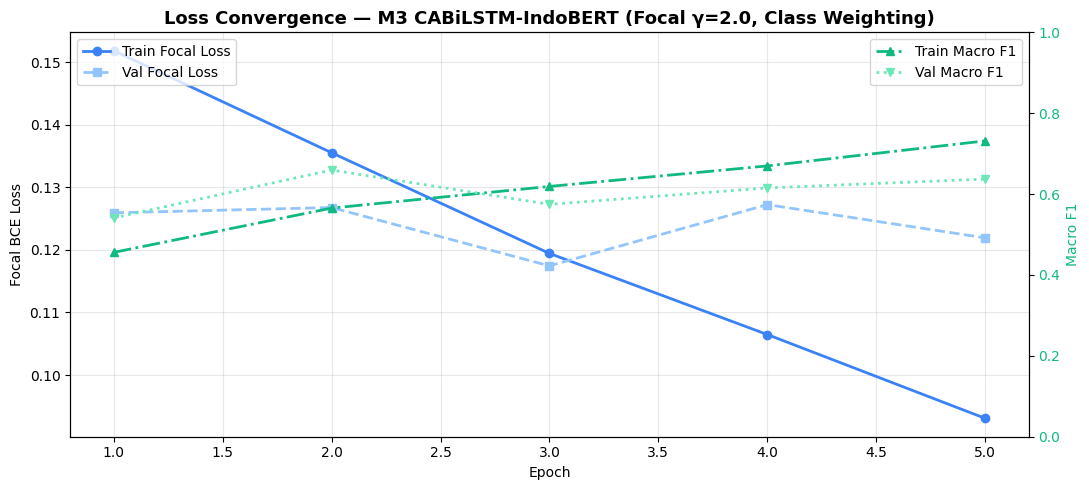

Saved: /kaggle/working/m3_loss_convergence.png


In [21]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-',  color='#3b82f6', label='Train Focal Loss', lw=2)
ax1.plot(epochs_range, history['val_loss'],   's--', color='#93c5fd', label='Val Focal Loss',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Focal BCE Loss'); ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['train_f1'], '^-.',  color='#10b981', label='Train Macro F1', lw=2)
ax2.plot(epochs_range, history['val_f1'],   'v:',   color='#6ee7b7', label='Val Macro F1',   lw=2)
ax2.set_ylabel('Macro F1', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.set_ylim([0, 1]); ax2.legend(loc='upper right')

plt.title(f'Loss Convergence — M3 CABiLSTM-IndoBERT (Focal γ={FOCAL_GAMMA}, Class Weighting)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_PLOT_PATH}')

---
## Section 11: Evaluasi Test Set

In [22]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
print(f'Loaded best model from epoch {best_epoch}')

test_loss, test_m, test_true, test_pred = eval_epoch(
    model, test_loader, device, pos_weight, FOCAL_GAMMA
)

print('\n' + '='*65)
print('TEST SET RESULTS — M3 (Focal Loss + Class Weighting)')
print('='*65)
print(f'Test Focal Loss        : {test_loss:.4f}')
print(f'Accuracy  (Pers. 2.15) : {test_m["accuracy"]:.4f}')
print(f'Macro Precision        : {test_m["macro_prec"]:.4f}')
print(f'Macro Recall           : {test_m["macro_rec"]:.4f}')
print(f'Macro F1   (Pers. 2.14): {test_m["macro_f1"]:.4f}')

Loaded best model from epoch 2


Eval :   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS — M3 (Focal Loss + Class Weighting)
Test Focal Loss        : 0.1139
Accuracy  (Pers. 2.15) : 0.6885
Macro Precision        : 0.5795
Macro Recall           : 0.6262
Macro F1   (Pers. 2.14): 0.5870


In [23]:
per_asp = compute_per_aspect_metrics(test_true, test_pred)
avg_f1  = float(np.mean([r['f1'] for r in per_asp]))

print('\nPer-Aspect Results (sentiment-only, no_aspect excluded):')
print(f'{"Aspect":<14} {"F1":>8} {"Prec":>8} {"Rec":>8} {"Acc":>8} {"N":>5}')
print('-'*55)
for r in per_asp:
    print(f'{r["aspect"]:<14} {r["f1"]:>8.4f} {r["precision"]:>8.4f} '
          f'{r["recall"]:>8.4f} {r["accuracy"]:>8.4f} {r["n_active"]:>5}')
print('-'*55)
print(f'{"MACRO AVG":<14} {avg_f1:>8.4f}')


Per-Aspect Results (sentiment-only, no_aspect excluded):
Aspect               F1     Prec      Rec      Acc     N
-------------------------------------------------------
PIGMENTATION     0.4420   0.4875   0.5438   0.4706    34
LONGEVITY        0.2609   0.2143   0.3333   0.6429    14
TEXTURE          0.4342   0.4231   0.4469   0.6667    21
HYDRATION        0.5307   0.5000   0.5852   0.8095    42
PRICE            1.0000   1.0000   1.0000   1.0000    11
-------------------------------------------------------
MACRO AVG        0.5336


In [24]:
# ── Per-class recall analysis (key metric for RQ2) ────────────────────────────
flat_true   = test_true.flatten()
flat_pred   = test_pred.flatten()
active_mask = flat_true != -1

print('Global Classification Report (active slots, 3-class):')
print(classification_report(
    flat_true[active_mask], flat_pred[active_mask],
    target_names=SENTIMENTS, digits=4, zero_division=0
))

# Per-class recall (to answer RQ2: did Focal Loss rescue minority classes?)
print('Per-class Recall (RQ2 — focus on negative & neutral):')
for i, s in enumerate(SENTIMENTS):
    mask_cls = flat_true[active_mask] == i
    if mask_cls.sum() > 0:
        rec = (flat_pred[active_mask][mask_cls] == i).sum() / mask_cls.sum()
    else:
        rec = 0.0
    marker = ' ← minority' if s in ['negative', 'neutral'] else ''
    print(f'  {s:<10}: {rec:.4f}{marker}')

Global Classification Report (active slots, 3-class):
              precision    recall  f1-score   support

    negative     0.5227    0.8214    0.6389        28
     neutral     0.3125    0.3571    0.3333        14
    positive     0.9032    0.7000    0.7887        80

    accuracy                         0.6885       122
   macro avg     0.5795    0.6262    0.5870       122
weighted avg     0.7481    0.6885    0.7021       122

Per-class Recall (RQ2 — focus on negative & neutral):
  negative  : 0.8214 ← minority
  neutral   : 0.3571 ← minority
  positive  : 0.7000


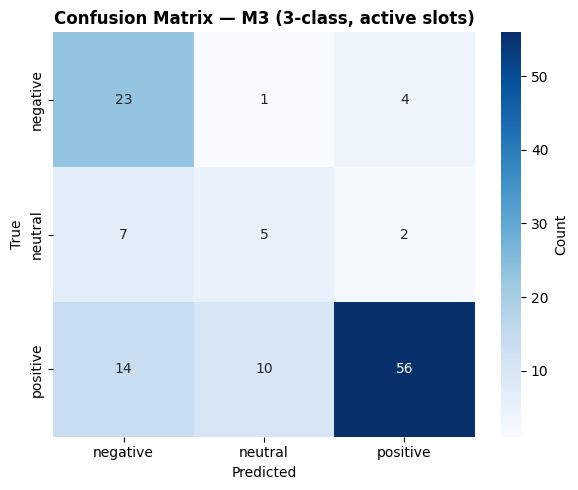

Saved: /kaggle/working/m3_confusion_matrix.png


In [25]:
cm = confusion_matrix(flat_true[active_mask], flat_pred[active_mask], labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENTS, yticklabels=SENTIMENTS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — M3 (3-class, active slots)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CM_PLOT_PATH}')

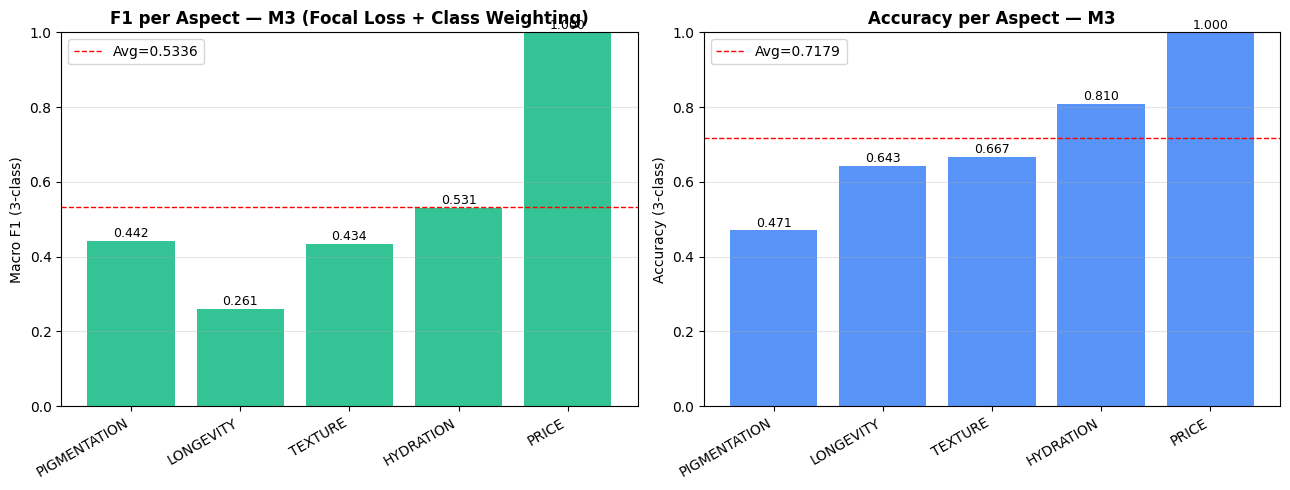

Saved: /kaggle/working/m3_per_aspect_results.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ASPECTS))

for ax, vals, ylabel, color in zip(
        axes,
        [[r['f1'] for r in per_asp], [r['accuracy'] for r in per_asp]],
        ['Macro F1 (3-class)', 'Accuracy (3-class)'],
        ['#10b981', '#3b82f6']):
    bars = ax.bar(x, vals, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ASPECTS, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_ylim([0, 1])
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=1,
               label=f'Avg={np.mean(vals):.4f}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_title('F1 per Aspect — M3 (Focal Loss + Class Weighting)', fontweight='bold')
axes[1].set_title('Accuracy per Aspect — M3', fontweight='bold')
plt.tight_layout()
plt.savefig(PERASPECT_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PERASPECT_PLOT_PATH}')

---
## Section 12: Hamming Loss (Proposal Persamaan 2.16)

In [27]:
D = test_true.shape[0]
L = test_true.shape[1]

mismatches   = (test_true != test_pred).sum()
hamming_loss = mismatches / (D * L)

print('='*55)
print('HAMMING LOSS (Proposal Persamaan 2.16)')
print('='*55)
print(f'|D| (reviews) : {D}')
print(f'|L| (aspects) : {L}')
print(f'Mismatches    : {mismatches}')
print(f'Hamming Loss  : {mismatches}/{D*L} = {hamming_loss:.4f}')
print(f'Hamming Acc   : {1-hamming_loss:.4f}')

print('\nPer-Aspect Hamming Loss:')
print(f'{"Aspect":<14} {"Mismatch":>10} {"HL":>8} {"HA":>8}')
print('-'*44)
per_asp_hl = []
for i, asp in enumerate(ASPECTS):
    mm = int((test_true[:, i] != test_pred[:, i]).sum())
    hl = mm / D
    per_asp_hl.append(hl)
    print(f'{asp:<14} {mm:>10} {hl:>8.4f} {1-hl:>8.4f}')
print('-'*44)
print(f'{"MACRO AVG":<14} {"":>10} {np.mean(per_asp_hl):>8.4f} {1-np.mean(per_asp_hl):>8.4f}')

HAMMING LOSS (Proposal Persamaan 2.16)
|D| (reviews) : 50
|L| (aspects) : 5
Mismatches    : 38
Hamming Loss  : 38/250 = 0.1520
Hamming Acc   : 0.8480

Per-Aspect Hamming Loss:
Aspect           Mismatch       HL       HA
--------------------------------------------
PIGMENTATION           18   0.3600   0.6400
LONGEVITY               5   0.1000   0.9000
TEXTURE                 7   0.1400   0.8600
HYDRATION               8   0.1600   0.8400
PRICE                   0   0.0000   1.0000
--------------------------------------------
MACRO AVG                   0.1520   0.8480


---
## Section 13: Save Predictions & Metrics

In [28]:
# ── Predictions CSV ───────────────────────────────────────────────────────────
pred_rows = [
    {
        'review_id' : test_df.iloc[i]['review_id'],
        'aspect'    : asp,
        'true_label': ID2SENT.get(test_true[i, j], 'no_aspect'),
        'pred_label': ID2SENT.get(test_pred[i, j], 'no_aspect'),
        'correct'   : test_true[i, j] == test_pred[i, j],
    }
    for i in range(len(test_df))
    for j, asp in enumerate(ASPECTS)
]
pd.DataFrame(pred_rows).to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics_out = {
    'model'             : 'M3_CABiLSTM_IndoBERT_FocalLoss_ClassWeighting',
    'config'            : CONFIG,
    'class_weights'     : {
        'sent_counts'   : sent_counts,
        'total_sentiment': int(total_sent),
        'weights'       : {s: float(w) for s, w in zip(SENTIMENTS, sent_weights)},
        'formula'       : 'N_total / (N_classes × N_c) — inverse frequency',
    },
    'focal_gamma'       : FOCAL_GAMMA,
    'best_epoch'        : int(best_epoch),
    'best_val_f1'       : float(best_val_f1),
    'test_loss'         : float(test_loss),
    'test_accuracy'     : float(test_m['accuracy']),
    'test_macro_f1'     : float(test_m['macro_f1']),
    'test_macro_prec'   : float(test_m['macro_prec']),
    'test_macro_rec'    : float(test_m['macro_rec']),
    'per_aspect'        : per_asp,
    'avg_per_aspect_f1' : float(avg_f1),
    'hamming_loss'      : {
        'formula'          : 'Proposal Persamaan 2.16',
        'D_reviews'        : int(D),
        'L_aspects'        : int(L),
        'overall'          : float(hamming_loss),
        'hamming_accuracy' : float(1 - hamming_loss),
        'per_aspect'       : {asp: float(hl) for asp, hl in zip(ASPECTS, per_asp_hl)},
    },
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f'Metrics  saved: {METRICS_PATH}')

print('\n' + '='*55)
print(f'✅ M3 complete — Test Macro F1: {test_m["macro_f1"]:.4f}')
print('='*55)

Predictions saved: /kaggle/working/m3_predictions.csv
Metrics  saved: /kaggle/working/m3_metrics.json

✅ M3 complete — Test Macro F1: 0.5870
